# Supermarket Sales — Data Cleaning & Visualization

## Project Objective
This notebook cleans the supermarket sales dataset, handles missing values, duplicates, and outliers, performs exploratory data analysis (EDA), and creates visualizations to discover useful business insights.

**Libraries:** Pandas, NumPy, Matplotlib, Seaborn


In [1]:
# Install libraries if required
# Uncomment the next line if libraries are not installed
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# ==============================
# ATTRACTIVE & COLORFUL CHART STYLE
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Custom color palette
COLORS = [
    "#6C5CE7", "#00B894", "#0984E3", "#E84393",
    "#FDCB6E", "#E17055", "#00CEC9", "#A29BFE"
]

# General chart style
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05
)

plt.rcParams.update({
    "figure.facecolor": "#F4F7FB",
    "axes.facecolor": "#FFFFFF",
    "axes.edgecolor": "#D9E2EC",
    "axes.labelcolor": "#263238",
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.titlepad": 15,
    "xtick.color": "#37474F",
    "ytick.color": "#37474F",
    "grid.color": "#DDE6EE",
    "grid.alpha": 0.55,
    "font.family": "DejaVu Sans"
})

print("Attractive chart style loaded!")


Attractive chart style loaded!


## 1. Load the Dataset

In [3]:
# Load the uploaded dataset
df = pd.read_csv("Supermarket Sales.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (1000, 20)


## 2. Understand the Dataset

In [4]:
print("First 5 rows:")
display(df.head())


First 5 rows:


,Invoice ID,Branch,CustomerID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude
0,750-67-8428,A,C1888,Yangon,Member,Female,Health and beauty,74.69,10,37.3450,746.90,21-02-2019,13:08,Ewallet,711.333333,4.761905,35.566667,9.1,96.1735,16.8409
1,226-31-3081,C,C1475,Naypyitaw,Normal,Female,Health and beauty,15.28,6,4.5840,91.68,27-05-2019,10:29,Cash,76.400000,4.761905,15.280000,10.0,96.0785,19.7633
2,631-41-3108,A,C1746,Yangon,Normal,Male,Health and beauty,46.33,7,16.2155,324.31,27-12-2019,13:23,Credit card,324.310000,4.761905,0.000000,7.4,96.1735,16.8409
3,123-19-1176,A,C1896,Yangon,Member,Male,Health and beauty,58.22,11,32.0210,640.42,15-11-2019,20:33,Ewallet,465.760000,4.761905,174.660000,8.4,96.1735,16.8409
4,373-73-7910,A,C1790,Yangon,Normal,Male,Health and beauty,86.31,7,30.2085,604.17,31-03-2019,10:37,Ewallet,604.170000,4.761905,0.000000,NaN,96.1735,16.8409


In [5]:
print("Last 5 rows:")
display(df.tail())


Last 5 rows:


,Invoice ID,Branch,CustomerID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude
995,233-67-5758,C,C1451,Naypyitaw,Normal,Male,Fashion accessories,40.35,1,2.0175,40.35,02-10-2019,13:46,Ewallet,40.35,4.761905,0.00,6.51,96.0785,19.7633
996,303-96-2227,B,C1204,Mandalay,Normal,Female,Fashion accessories,97.38,14,68.1660,1363.32,29-12-2019,17:16,Ewallet,973.80,4.761905,389.52,5.28,96.0891,21.9588
997,727-02-1313,A,C1678,Yangon,Member,Male,Fashion accessories,31.84,1,1.5920,31.84,16-01-2019,13:22,Cash,31.84,4.761905,0.00,7.70,96.1735,16.8409
998,347-56-2442,A,C1661,Yangon,Normal,Male,Fashion accessories,65.82,1,3.2910,65.82,21-03-2019,15:33,Cash,65.82,4.761905,0.00,4.10,96.1735,16.8409
999,849-09-3807,A,C1647,Yangon,Member,Female,Fashion accessories,88.34,10,44.1700,883.40,11-10-2019,13:28,Cash,618.38,4.761905,265.02,6.60,96.1735,16.8409


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape: (1000, 20)

Column Names:
['Invoice ID', 'Branch', 'CustomerID', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating', 'Longitude', 'Latitude']


In [7]:
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   806 non-null    object 
 2   CustomerID               1000 non-null   object 
 3   City                     1000 non-null   object 
 4   Customer type            952 non-null    object 
 5   Gender                   975 non-null    object 
 6   Product line             977 non-null    object 
 7   Unit price               1000 non-null   float64
 8   Quantity                 1000 non-null   int64  
 9   Tax 5%                   896 non-null    float64
 10  Total                    1000 non-null   float64
 11  Date                     1000 non-null   object 
 12  Time                     1000 non-null   object 
 13  Payment                  979 non-null    object 
 14  cogs

In [8]:
print("Statistical Summary:")
display(df.describe(include="all").T)


Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice ID,1000,1000,750-67-8428,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,806,3,A,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,1000,471,C1212,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,3,Yangon,340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer type,952,2,Normal,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,975,2,Female,493,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product line,977,6,Health and beauty,289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit price,1000.0,NaN,NaN,NaN,55.67213,26.494628,10.08,32.875,55.23,77.935,99.96
Quantity,1000.0,NaN,NaN,NaN,7.485,4.520643,1.0,4.0,7.0,11.0,20.0
Tax 5%,896.0,NaN,NaN,NaN,20.96693,17.604704,0.5085,7.4795,15.46825,30.205875,87.498


## 3. Check Missing Values

In [9]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
})

display(missing_table)


,Missing Values,Percentage
Invoice ID,0,0.0
Branch,194,19.4
CustomerID,0,0.0
City,0,0.0
Customer type,48,4.8
Gender,25,2.5
Product line,23,2.3
Unit price,0,0.0
Quantity,0,0.0
Tax 5%,104,10.4


### Handle Missing Values

In [10]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if not df[column].mode().empty:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
Invoice ID                 0
Branch                     0
CustomerID                 0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Longitude                  0
Latitude                   0
dtype: int64


## 4. Check and Remove Duplicates

In [11]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())


Duplicate rows: 0
Shape after removing duplicates: (1000, 20)
Remaining duplicates: 0


## 5. Data Type Conversion

In [12]:
# Convert Date column to datetime when available
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.dtypes)


Invoice ID                         object
Branch                             object
CustomerID                         object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
Longitude                         float64
Latitude                          float64
dtype: object


C:\Users\DARSH\AppData\Local\Temp\ipykernel_28376\2589480659.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


## 6. Feature Creation

In [13]:
if "Date" in df.columns:
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["Day_Name"] = df["Date"].dt.day_name()

display(df.head())


,Invoice ID,Branch,CustomerID,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Longitude,Latitude,Year,Month,Day,Day_Name
0,750-67-8428,A,C1888,Yangon,Member,Female,Health and beauty,74.69,10,37.3450,746.90,2019-02-21,13:08,Ewallet,711.333333,4.761905,35.566667,9.100,96.1735,16.8409,2019,2,21,Thursday
1,226-31-3081,C,C1475,Naypyitaw,Normal,Female,Health and beauty,15.28,6,4.5840,91.68,2019-05-27,10:29,Cash,76.400000,4.761905,15.280000,10.000,96.0785,19.7633,2019,5,27,Monday
2,631-41-3108,A,C1746,Yangon,Normal,Male,Health and beauty,46.33,7,16.2155,324.31,2019-12-27,13:23,Credit card,324.310000,4.761905,0.000000,7.400,96.1735,16.8409,2019,12,27,Friday
3,123-19-1176,A,C1896,Yangon,Member,Male,Health and beauty,58.22,11,32.0210,640.42,2019-11-15,20:33,Ewallet,465.760000,4.761905,174.660000,8.400,96.1735,16.8409,2019,11,15,Friday
4,373-73-7910,A,C1790,Yangon,Normal,Male,Health and beauty,86.31,7,30.2085,604.17,2019-03-31,10:37,Ewallet,604.170000,4.761905,0.000000,7.455,96.1735,16.8409,2019,3,31,Sunday


## 7. Outlier Detection

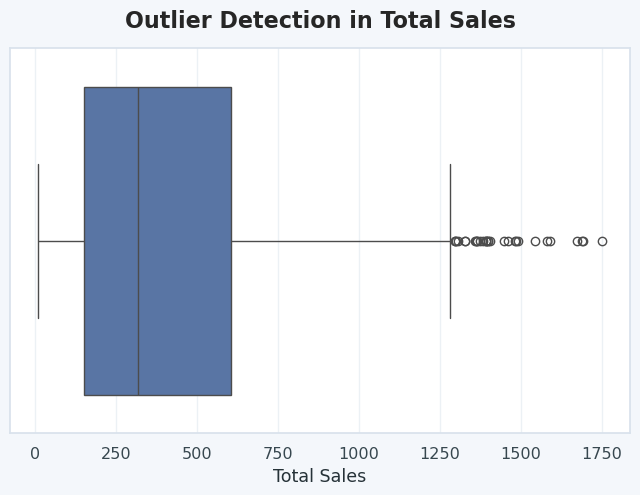

In [14]:
# Boxplot for Total sales
if "Total" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=df["Total"])
    plt.title("Outlier Detection in Total Sales")
    plt.xlabel("Total Sales")
    plt.show()


In [15]:
# IQR method for Total sales
if "Total" in df.columns:
    Q1 = df["Total"].quantile(0.25)
    Q3 = df["Total"].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[(df["Total"] < lower_limit) | (df["Total"] > upper_limit)]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of outliers:", len(outliers))


Q1: 152.745
Q3: 605.2225
IQR: 452.47749999999996
Lower Limit: -525.9712499999999
Upper Limit: 1283.9387499999998
Number of outliers: 30


In [16]:
# Create cleaned dataset after outlier treatment
if "Total" in df.columns:
    df_clean = df[
        (df["Total"] >= lower_limit) &
        (df["Total"] <= upper_limit)
    ].copy()
else:
    df_clean = df.copy()

print("Original rows:", len(df))
print("Rows after outlier treatment:", len(df_clean))


Original rows: 1000
Rows after outlier treatment: 970


## 8. Save Cleaned Dataset

In [17]:
df_clean.to_csv("cleaned_sales.csv", index=False)
print("Cleaned dataset saved as cleaned_sales.csv")


Cleaned dataset saved as cleaned_sales.csv


## 9. Exploratory Data Analysis (EDA)

### 9.1 Sales by Product Line

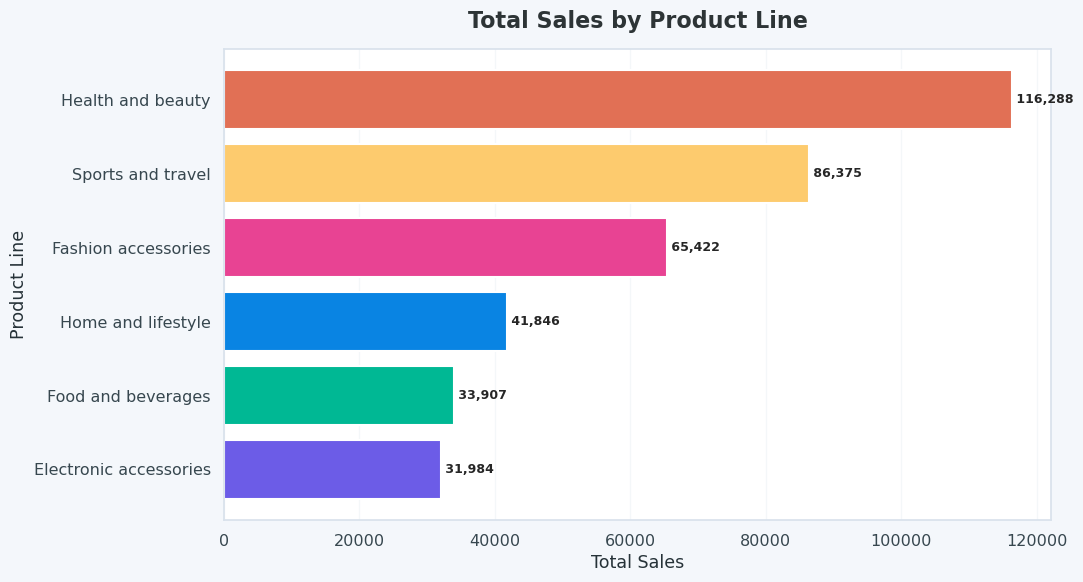

,Total Sales
Product line,
Electronic accessories,31983.81
Food and beverages,33907.05
Home and lifestyle,41846.28
Fashion accessories,65422.03
Sports and travel,86375.14
Health and beauty,116288.04


In [18]:
if {"Product line", "Total"}.issubset(df_clean.columns):
    product_sales = df_clean.groupby("Product line")["Total"].sum().sort_values()

    fig, ax = plt.subplots(figsize=(11, 6), facecolor="#F4F7FB")
    ax.set_facecolor("#FFFFFF")

    bars = ax.barh(
        product_sales.index,
        product_sales.values,
        color=COLORS[:len(product_sales)],
        edgecolor="white",
        linewidth=1.5
    )

    ax.set_title("Total Sales by Product Line", color="#2D3436")
    ax.set_xlabel("Total Sales")
    ax.set_ylabel("Product Line")

    for bar in bars:
        ax.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f" {bar.get_width():,.0f}",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

    ax.grid(axis="x", alpha=0.3)
    ax.grid(axis="y", visible=False)
    plt.tight_layout()
    plt.show()

    display(product_sales.to_frame("Total Sales"))


### 9.2 Sales by Branch

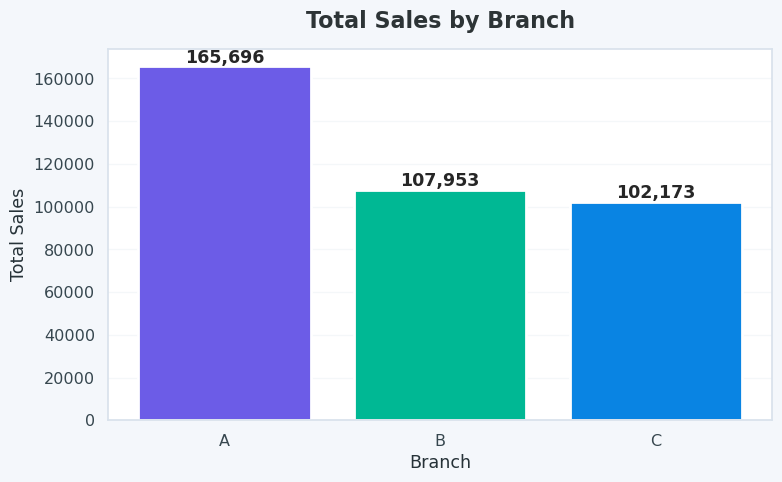

,Total Sales
Branch,
A,165696.23
B,107953.46
C,102172.66


In [19]:
if {"Branch", "Total"}.issubset(df_clean.columns):
    branch_sales = df_clean.groupby("Branch")["Total"].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F4F7FB")
    ax.set_facecolor("#FFFFFF")

    bars = ax.bar(
        branch_sales.index,
        branch_sales.values,
        color=["#6C5CE7", "#00B894", "#0984E3"],
        edgecolor="white",
        linewidth=2
    )

    ax.set_title("Total Sales by Branch", color="#2D3436")
    ax.set_xlabel("Branch")
    ax.set_ylabel("Total Sales")

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", visible=False)
    plt.tight_layout()
    plt.show()

    display(branch_sales.to_frame("Total Sales"))


### 9.3 Sales by Gender

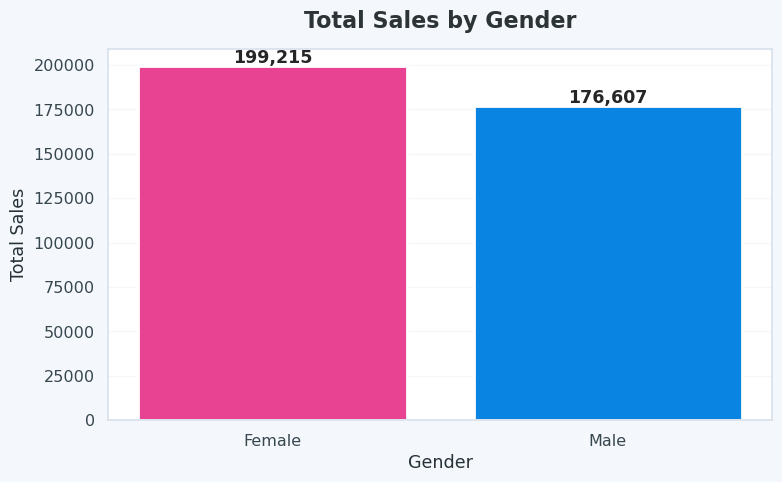

,Total Sales
Gender,
Female,199215.02
Male,176607.33


In [20]:
if {"Gender", "Total"}.issubset(df_clean.columns):
    gender_sales = df_clean.groupby("Gender")["Total"].sum()

    fig, ax = plt.subplots(figsize=(8, 5), facecolor="#F4F7FB")
    ax.set_facecolor("#FFFFFF")

    bars = ax.bar(
        gender_sales.index,
        gender_sales.values,
        color=["#E84393", "#0984E3"],
        edgecolor="white",
        linewidth=2
    )

    ax.set_title("Total Sales by Gender", color="#2D3436")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Total Sales")

    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{bar.get_height():,.0f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    ax.grid(axis="y", alpha=0.3)
    ax.grid(axis="x", visible=False)
    plt.tight_layout()
    plt.show()

    display(gender_sales.to_frame("Total Sales"))


### 9.4 Payment Method Distribution

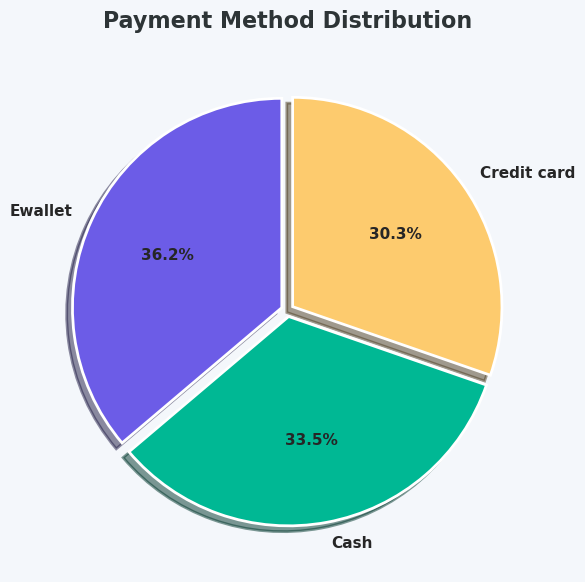

,Number of Transactions
Payment,
Ewallet,351
Cash,325
Credit card,294


In [21]:
if "Payment" in df_clean.columns:
    payment_count = df_clean["Payment"].value_counts()

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="#F4F7FB")

    wedges, texts, autotexts = ax.pie(
        payment_count.values,
        labels=payment_count.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=["#6C5CE7", "#00B894", "#FDCB6E"],
        explode=[0.03] * len(payment_count),
        shadow=True,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 11, "fontweight": "bold"}
    )

    ax.set_title("Payment Method Distribution", color="#2D3436")
    plt.tight_layout()
    plt.show()

    display(payment_count.to_frame("Number of Transactions"))


### 9.5 Quantity vs Total Sales

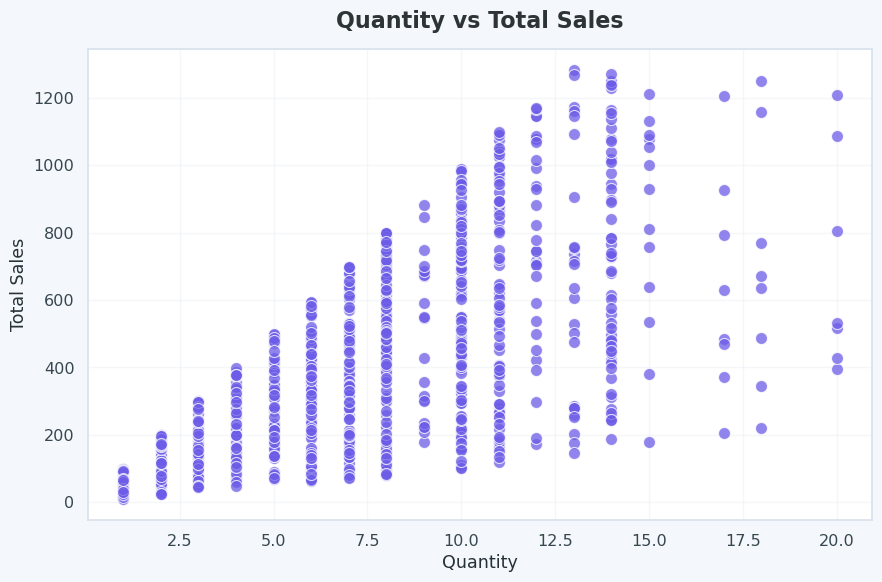

In [22]:
if {"Quantity", "Total"}.issubset(df_clean.columns):
    fig, ax = plt.subplots(figsize=(9, 6), facecolor="#F4F7FB")
    ax.set_facecolor("#FFFFFF")

    sns.scatterplot(
        data=df_clean,
        x="Quantity",
        y="Total",
        s=75,
        alpha=0.75,
        color="#6C5CE7",
        edgecolor="white",
        linewidth=0.8,
        ax=ax
    )

    ax.set_title("Quantity vs Total Sales", color="#2D3436")
    ax.set_xlabel("Quantity")
    ax.set_ylabel("Total Sales")

    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 9.6 Customer Rating Distribution

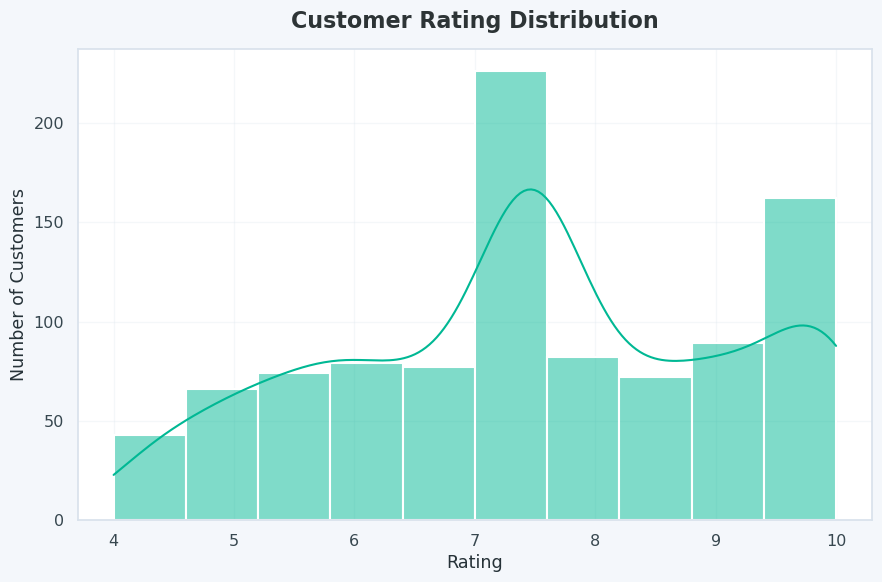

In [23]:
if "Rating" in df_clean.columns:
    fig, ax = plt.subplots(figsize=(9, 6), facecolor="#F4F7FB")
    ax.set_facecolor("#FFFFFF")

    sns.histplot(
        data=df_clean,
        x="Rating",
        bins=10,
        kde=True,
        color="#00B894",
        edgecolor="white",
        linewidth=1.5,
        ax=ax
    )

    ax.set_title("Customer Rating Distribution", color="#2D3436")
    ax.set_xlabel("Rating")
    ax.set_ylabel("Number of Customers")

    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


### 9.7 Daily Sales Trend

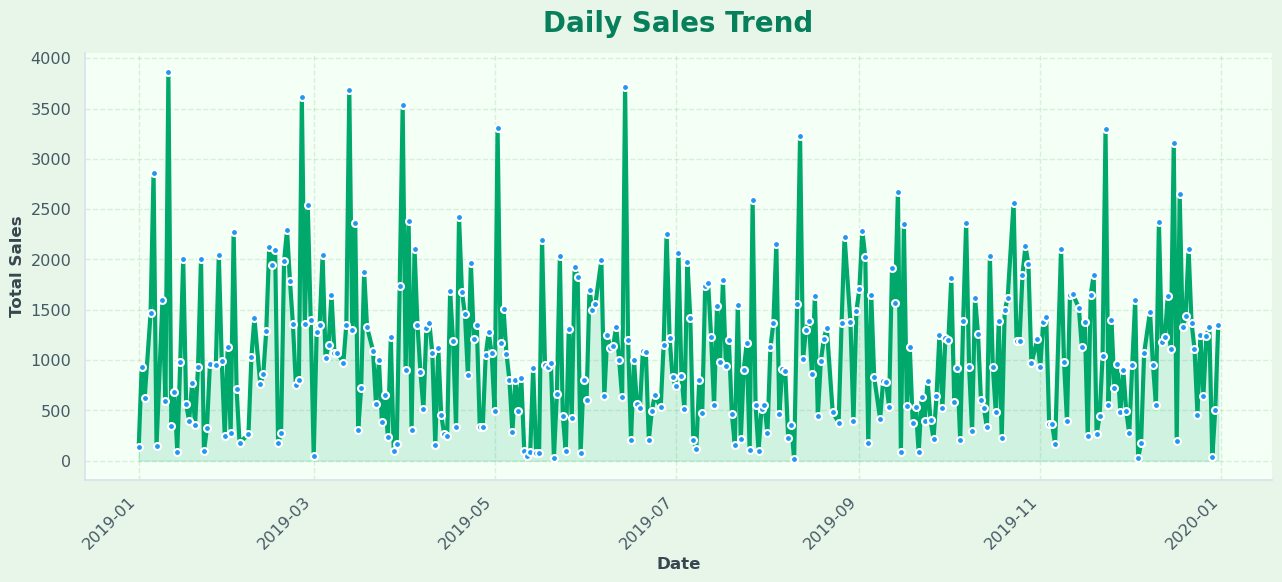

In [24]:
if {"Date", "Total"}.issubset(df_clean.columns):

    daily_sales = df_clean.groupby("Date")["Total"].sum()

    # Green + Blue Background
    fig, ax = plt.subplots(
        figsize=(13, 6),
        facecolor="#E8F5E9"       # Light Green Background
    )

    # Chart background
    ax.set_facecolor("#F4FFF6")

    # Sales Line
    ax.plot(
        daily_sales.index,
        daily_sales.values,
        color="#00A86B",          # Green
        linewidth=3,
        marker="o",
        markersize=5,
        markerfacecolor="#2196F3", # Blue
        markeredgecolor="white",
        markeredgewidth=1.5
    )

    # Filled Area
    ax.fill_between(
        daily_sales.index,
        daily_sales.values,
        alpha=0.15,
        color="#00A86B"
    )

    # Title
    ax.set_title(
        "Daily Sales Trend",
        fontsize=20,
        fontweight="bold",
        color="#087F5B",
        pad=15
    )

    # X-axis
    ax.set_xlabel(
        "Date",
        fontsize=12,
        fontweight="bold",
        color="#37474F"
    )

    # Y-axis
    ax.set_ylabel(
        "Total Sales",
        fontsize=12,
        fontweight="bold",
        color="#37474F"
    )

    # Grid
    ax.grid(
        alpha=0.25,
        color="#81C784",
        linestyle="--"
    )

    # Tick colors
    ax.tick_params(
        colors="#455A64"
    )

    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Rotate dates
    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

### 9.8 Correlation Heatmap

C:\Users\DARSH\AppData\Local\Temp\ipykernel_28376\419286879.py:17: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


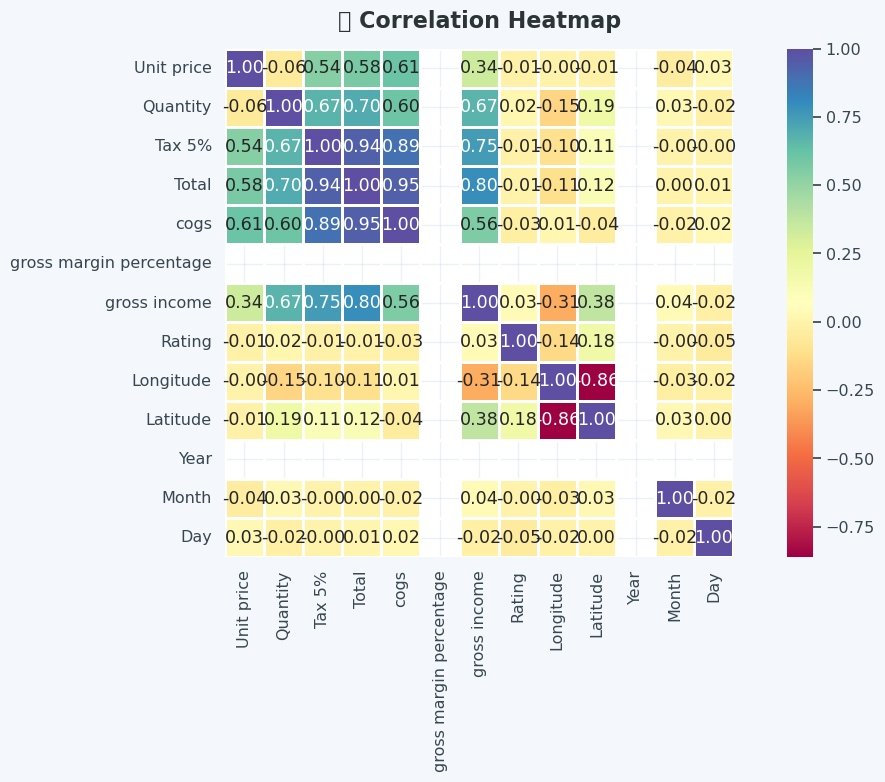

In [25]:
numeric_df = df_clean.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(12, 8), facecolor="#F4F7FB")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Spectral",
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    square=True,
    ax=ax
)

ax.set_title("🔥 Correlation Heatmap", color="#2D3436")
plt.tight_layout()
plt.show()


## 10. Key Business Insights

In [26]:
# Generate important summary values

if "Total" in df_clean.columns:
    print("Total Sales:", round(df_clean["Total"].sum(), 2))
    print("Average Transaction Value:", round(df_clean["Total"].mean(), 2))

if {"Product line", "Total"}.issubset(df_clean.columns):
    best_product = df_clean.groupby("Product line")["Total"].sum().idxmax()
    print("Best Product Line:", best_product)

if {"Branch", "Total"}.issubset(df_clean.columns):
    best_branch = df_clean.groupby("Branch")["Total"].sum().idxmax()
    print("Best Branch:", best_branch)

if "Payment" in df_clean.columns:
    popular_payment = df_clean["Payment"].value_counts().idxmax()
    print("Most Used Payment Method:", popular_payment)

if "Rating" in df_clean.columns:
    print("Average Customer Rating:", round(df_clean["Rating"].mean(), 2))


Total Sales: 375822.35
Average Transaction Value: 387.45
Best Product Line: Health and beauty
Best Branch: A
Most Used Payment Method: Ewallet
Average Customer Rating: 7.47


## 11. Final Dashboard

The following dashboard combines the main findings into one visual report.


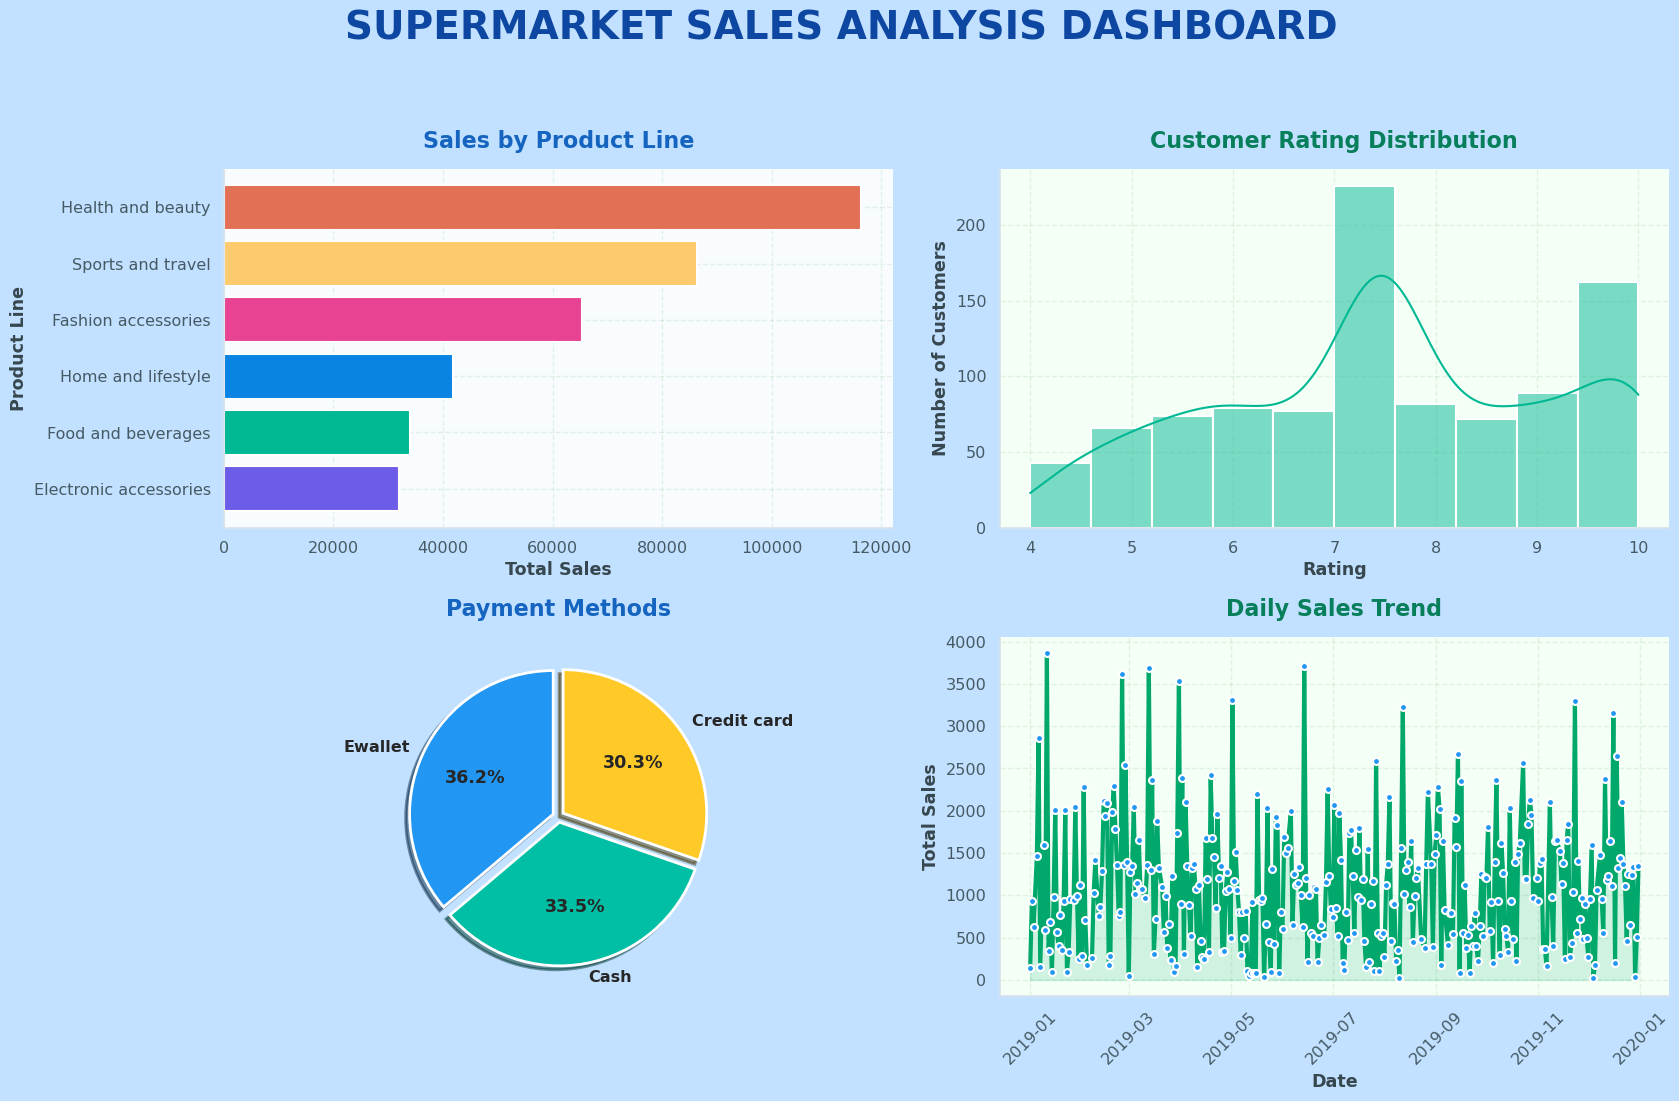

In [39]:
# ==============================
# ATTRACTIVE BLUE + GREEN DASHBOARD
# ==============================

fig, axes = plt.subplots(
    2, 2,
    figsize=(17, 11),
    facecolor="#C2E0FF"
)

# ==============================
# 1. PRODUCT LINE
# ==============================

if {"Product line", "Total"}.issubset(df_clean.columns):

    product_sales = (
        df_clean.groupby("Product line")["Total"]
        .sum()
        .sort_values()
    )

    axes[0, 0].set_facecolor("#F8FCFF")

    axes[0, 0].barh(
        product_sales.index,
        product_sales.values,
        color=COLORS[:len(product_sales)],
        edgecolor="white",
        linewidth=1.5
    )

    axes[0, 0].set_title(
        "Sales by Product Line",
        fontsize=16,
        fontweight="bold",
        color="#1565C0"
    )

    axes[0, 0].set_xlabel(
        "Total Sales",
        color="#37474F",
        fontweight="bold"
    )

    axes[0, 0].set_ylabel(
        "Product Line",
        color="#37474F",
        fontweight="bold"
    )


# ==============================
# 2. CUSTOMER RATING DISTRIBUTION
# ==============================

if "Rating" in df_clean.columns:

    axes[0, 1].set_facecolor("#F4FFF6")

    sns.histplot(
        data=df_clean,
        x="Rating",
        bins=10,
        kde=True,
        color="#00B894",
        edgecolor="white",
        linewidth=1.5,
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        "Customer Rating Distribution",
        fontsize=16,
        fontweight="bold",
        color="#087F5B"
    )

    axes[0, 1].set_xlabel(
        "Rating",
        color="#37474F",
        fontweight="bold"
    )

    axes[0, 1].set_ylabel(
        "Number of Customers",
        color="#37474F",
        fontweight="bold"
    )


# ==============================
# 3. PAYMENT METHODS
# ==============================

if "Payment" in df_clean.columns:

    payment_count = df_clean["Payment"].value_counts()

    axes[1, 0].set_facecolor("#F8FCFF")

    axes[1, 0].pie(
        payment_count.values,
        labels=payment_count.index,
        autopct="%1.1f%%",
        startangle=90,

        colors=[
            "#2196F3",
            "#00BFA5",
            "#FFCA28"
        ],

        explode=[0.04] * len(payment_count),

        shadow=True,

        wedgeprops={
            "edgecolor": "white",
            "linewidth": 2
        },

        textprops={
            "fontweight": "bold"
        }
    )

    axes[1, 0].set_title(
        "Payment Methods",
        fontsize=16,
        fontweight="bold",
        color="#1565C0"
    )


# ==============================
# 4. DAILY SALES TREND
# ==============================

if {"Date", "Total"}.issubset(df_clean.columns):

    # Convert Date to datetime
    df_clean["Date"] = pd.to_datetime(
        df_clean["Date"],
        errors="coerce"
    )

    daily_sales = (
        df_clean.dropna(subset=["Date"])
        .groupby("Date")["Total"]
        .sum()
        .sort_index()
    )

    axes[1, 1].set_facecolor("#F4FFF6")

    # Sales Line
    axes[1, 1].plot(
        daily_sales.index,
        daily_sales.values,
        color="#00A86B",
        linewidth=3,
        marker="o",
        markersize=5,
        markerfacecolor="#2196F3",
        markeredgecolor="white",
        markeredgewidth=1.5
    )

    # Filled Area
    axes[1, 1].fill_between(
        daily_sales.index,
        daily_sales.values,
        alpha=0.15,
        color="#00A86B"
    )

    axes[1, 1].set_title(
        "Daily Sales Trend",
        fontsize=16,
        fontweight="bold",
        color="#087F5B"
    )

    axes[1, 1].set_xlabel(
        "Date",
        color="#37474F",
        fontweight="bold"
    )

    axes[1, 1].set_ylabel(
        "Total Sales",
        color="#37474F",
        fontweight="bold"
    )

    axes[1, 1].tick_params(
        axis="x",
        rotation=45
    )


# ==============================
# GRID & AXIS SETTINGS
# ==============================

for ax in axes.flat:

    ax.grid(
        alpha=0.20,
        color="#81C784",
        linestyle="--"
    )

    ax.tick_params(
        colors="#455A64"
    )

    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ==============================
# MAIN DASHBOARD TITLE
# ==============================

fig.suptitle(
    "SUPERMARKET SALES ANALYSIS DASHBOARD",
    fontsize=28,
    fontweight="bold",
    color="#0D47A1",
    y=1
)


# ==============================
# FINAL LAYOUT
# ==============================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

## Conclusion

The project successfully demonstrates a complete data analysis workflow:

1. Loaded raw supermarket sales data.
2. Explored the dataset and its structure.
3. Checked and handled missing values.
4. Removed duplicate records.
5. Converted date values into a useful format.
6. Detected and treated outliers using the IQR method.
7. Created additional date-based features.
8. Performed exploratory data analysis.
9. Created multiple visualizations.
10. Generated business insights and a final dashboard.

**Skills demonstrated:** Python, Pandas, NumPy, Matplotlib, Seaborn, Data Cleaning, EDA, Data Visualization, and Data Storytelling.
